# Thermal-Aware Energy Management System — Summary of Results

This notebook summarizes the key results of the project, drawing on saved outputs from
`03_multi_lap_DP.ipynb` and `04_multu_lap_DP_thermal.ipynb` rather than recomputing the dynamic programming
solutions here (each backward pass takes long enough that recomputing three variants plus
a thermal stress test in one notebook is impractical).

**Story in four parts:**
1. A fuel-optimal baseline strategy over a 5-lap race is found, but it is not repeatable lap to lap and causes a power shortfall in the closing laps.
2. An asymmetric soft constraint on end-of-lap SoC restores repeatability, at a quantified fuel cost.
3. A parametric cooling-degradation stress test characterizes when thermal derating becomes the binding constraint, since at nominal cooling it never is.
4. A fixed-point iteration between the DP policy and the thermal model corrects the open-loop assumption once the thermal bound starts to bind, without a full 3D state reformulation.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

multi_lap = np.load('/app/data/results/multi_lap_comparison.npz')
thermal = np.load('/app/data/results/thermal_analysis.npz')

t = multi_lap['t']
N_lap = multi_lap['N_lap']
Pgb = multi_lap['Pgb']

## 1. Baseline: fuel-optimal but not repeatable

The pure fuel-minimizing strategy (no terminal SoC constraint) has no incentive to preserve
any charge for later laps: SoC is driven down within the first two laps and stays near its
floor for the rest of the race. This is the correct optimum for the objective as stated, not
a bug, but it has a direct consequence: once SoC is exhausted, delivered power is capped by
the engine alone, and a shortfall appears against the requested power in the closing laps.


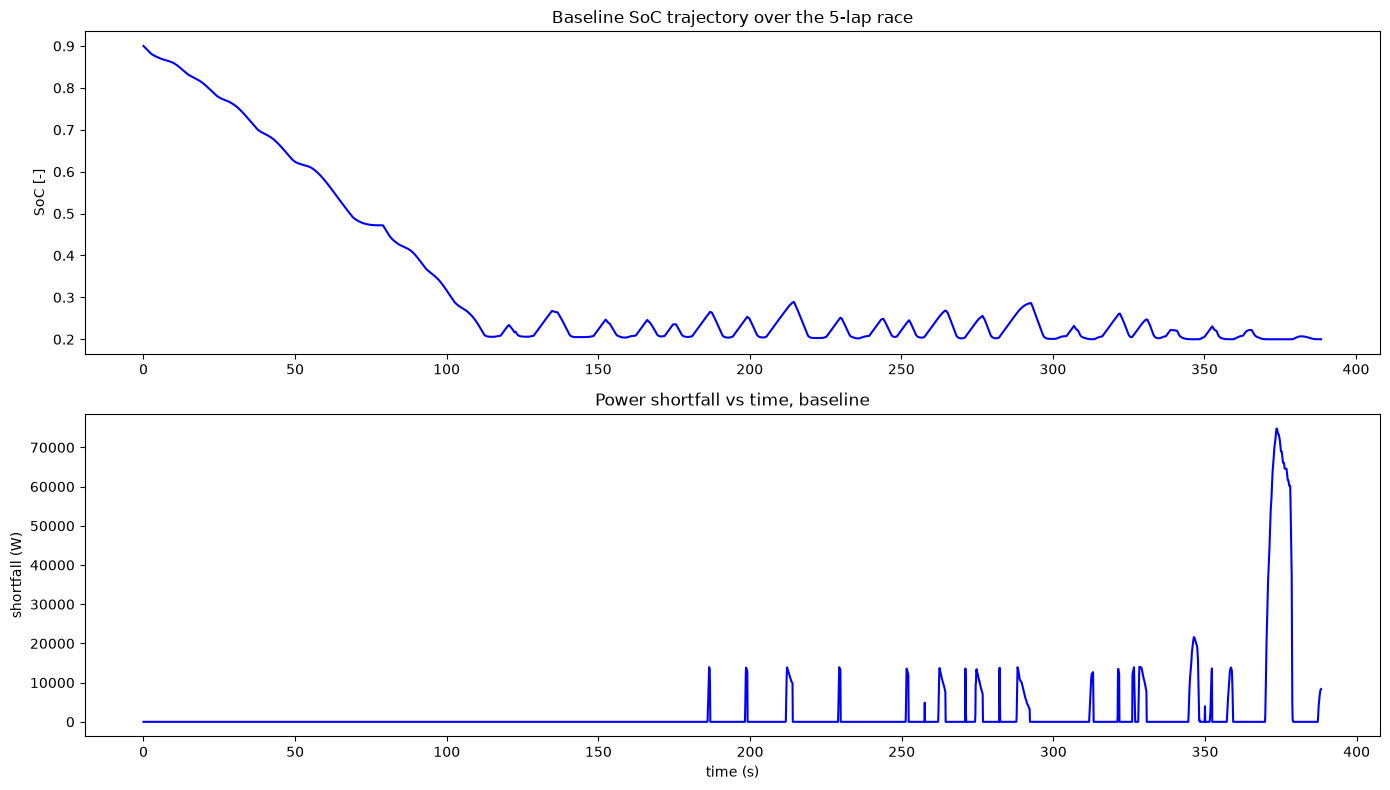

Baseline total fuel: 3578.89 g
Baseline total shortfall energy: 0.853 MJ


In [8]:
fig, axs = plt.subplots(2, 1, figsize=(14, 8))

axs[0].plot(t, multi_lap['SoC_baseline'], color='blue')
axs[0].set_ylabel('SoC [-]')
axs[0].set_title('Baseline SoC trajectory over the 5-lap race')

delivered_baseline = multi_lap['P_eng_baseline'] + multi_lap['P_mgu_baseline']
shortfall_baseline = np.maximum(0, Pgb - delivered_baseline)
axs[1].plot(t[0:-2], shortfall_baseline[0:-2], color='blue')
axs[1].set_xlabel('time (s)')
axs[1].set_ylabel('shortfall (W)')
axs[1].set_title('Power shortfall vs time, baseline')

plt.tight_layout()
plt.show()

print(f"Baseline total fuel: {np.sum(multi_lap['J_baseline'])*1e3:.2f} g")
print(f"Baseline total shortfall energy: {np.sum(shortfall_baseline)*0.1/1e6:.3f} MJ")

## 2. Restoring repeatability: asymmetric soft constraint on end-of-lap SoC

Rather than an equality target (which would penalize ending a lap with more charge than
needed, never a feasibility problem, only a fuel inefficiency the cost already accounts for),
a one-sided hinge penalty is added to the value function at every lap boundary, pushing SoC
upward only when it falls below a target. Two variants are compared against the baseline:
a fixed target (0.7 every lap) and a lap-dependent target, raised only in the later laps
where the baseline actually showed a shortfall.


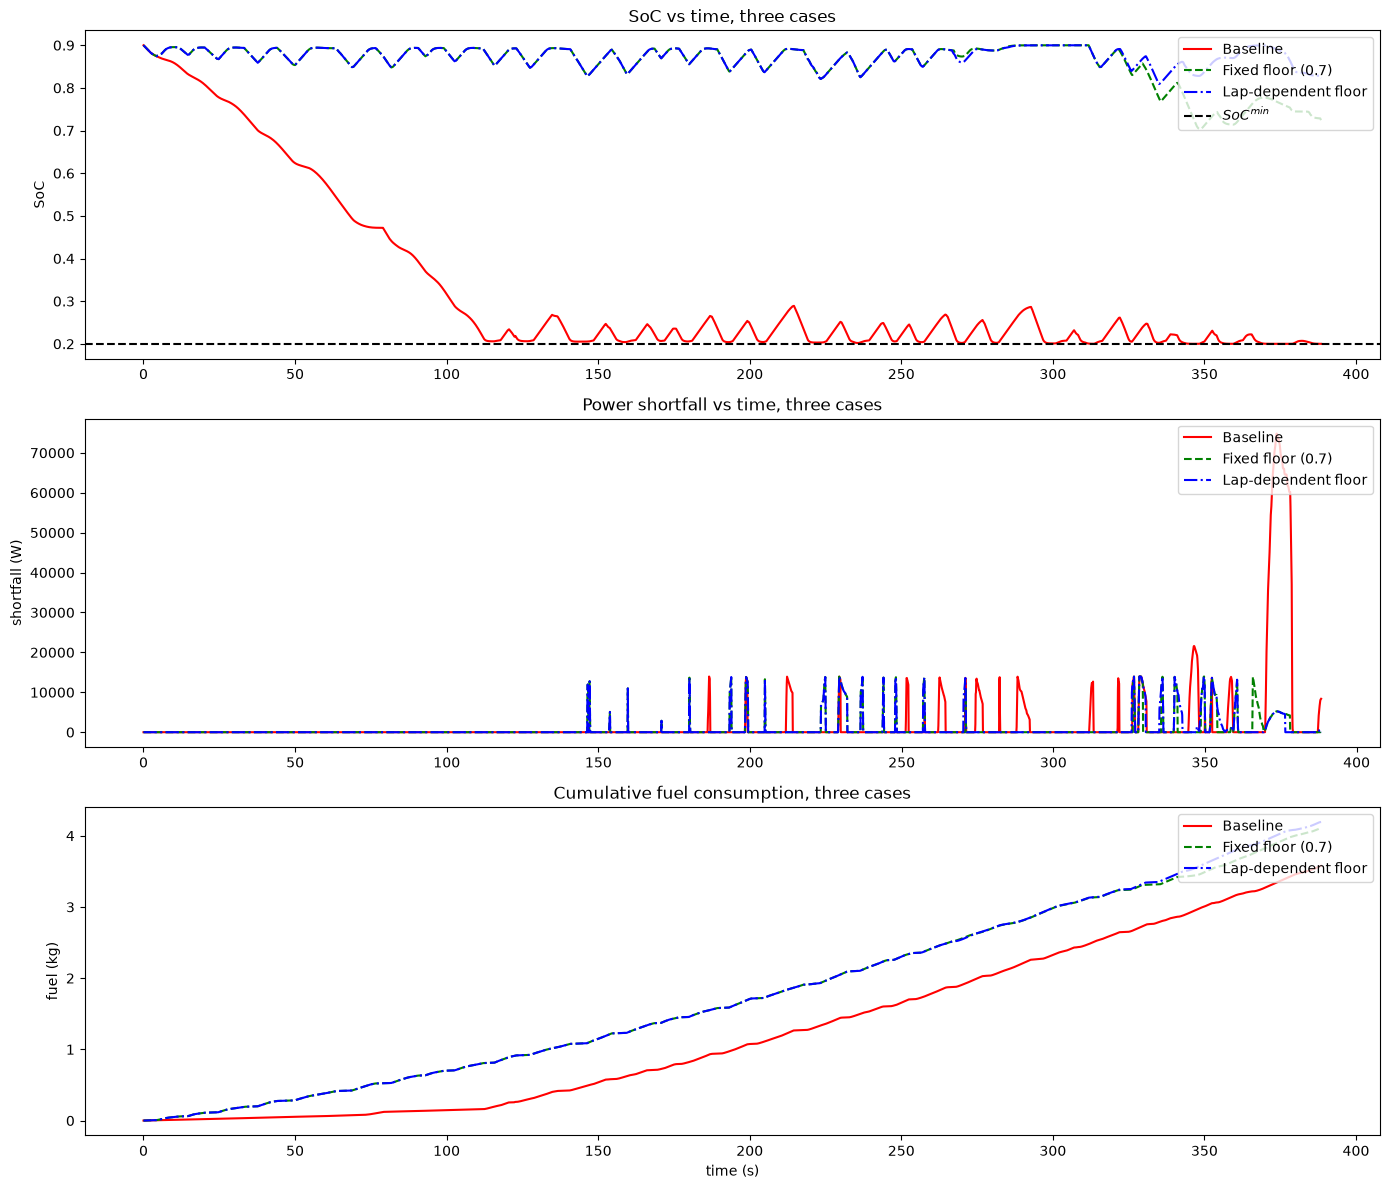

Case                    Fuel (g)    Shortfall energy (MJ)
Baseline                 3578.89                    0.853
Fixed floor (0.7)        4106.63                    0.300
Lap-dependent floor      4193.15                    0.316


In [9]:
fig, axs = plt.subplots(3, 1, figsize=(14, 12))
labels = {'baseline': ('Baseline', 'red', '-'), 'fixed': ('Fixed floor (0.7)', 'green','--'), 'variable': ('Lap-dependent floor', 'blue','-.')}

for key, (label, color, linestyle) in labels.items():
    axs[0].plot(t, multi_lap[f'SoC_{key}'], color=color, label=label, linestyle=linestyle)
axs[0].axhline(0.2, color='k', linestyle='--', label=r'$SoC^{min}$')
axs[0].set_ylabel('SoC')
axs[0].set_title('SoC vs time, three cases')
axs[0].legend(loc=1)

for key, (label, color, linestyle) in labels.items():
    delivered = multi_lap[f'P_eng_{key}'] + multi_lap[f'P_mgu_{key}']
    shortfall = np.maximum(0, Pgb - delivered)
    axs[1].plot(t[0:-2], shortfall[0:-2], color=color, label=label, linestyle= linestyle)
axs[1].set_ylabel('shortfall (W)')
axs[1].set_title('Power shortfall vs time, three cases')
axs[1].legend(loc=1)

for key, (label, color,linestyle) in labels.items():
    axs[2].plot(t, np.cumsum(multi_lap[f'J_{key}']), color=color, label=label, linestyle=linestyle)
axs[2].set_xlabel('time (s)')
axs[2].set_ylabel('fuel (kg)')
axs[2].set_title('Cumulative fuel consumption, three cases')
axs[2].legend(loc=1)

plt.tight_layout()
plt.show()

print(f"{'Case':<20}{'Fuel (g)':>12}{'Shortfall energy (MJ)':>25}")
for key, (label, _,_) in labels.items():
    fuel = np.sum(multi_lap[f'J_{key}'])*1e3
    delivered = multi_lap[f'P_eng_{key}'] + multi_lap[f'P_mgu_{key}']
    shortfall_energy = np.sum(np.maximum(0, Pgb - delivered))*0.1/1e6
    print(f"{label:<20}{fuel:>12.2f}{shortfall_energy:>25.3f}")


**Reading the trade-off**: both soft-constraint variants reduce or eliminate the
closing-lap shortfall relative to the baseline, at a fuel cost. The result is not
the one the lap-dependent floor was designed to produce: it is dominated by the
simpler fixed floor, with both higher fuel consumption and slightly higher
shortfall energy, confirmed across two different lap-dependent schedules rather
than a single mistuned one. For this five-lap profile, a constant floor is more
fuel-efficient than a targeted one, an outcome reported here as found rather than
adjusted to match the original expectation.

## 3. When does the thermal constraint matter?

At nominal cooling, SoC exhaustion is always the binding constraint before the battery is hot
enough for thermal derating to matter: the DP already requests little power once SoC is low,
so the two constraints never overlap in time for this race profile. Since the thermal
parameters are estimated rather than calibrated against a real component, and no 2026
telemetry exists yet for tracks with more demanding thermal conditions, this is characterized
through a parametric stress test on cooling effectiveness rather than a track-to-track
comparison.


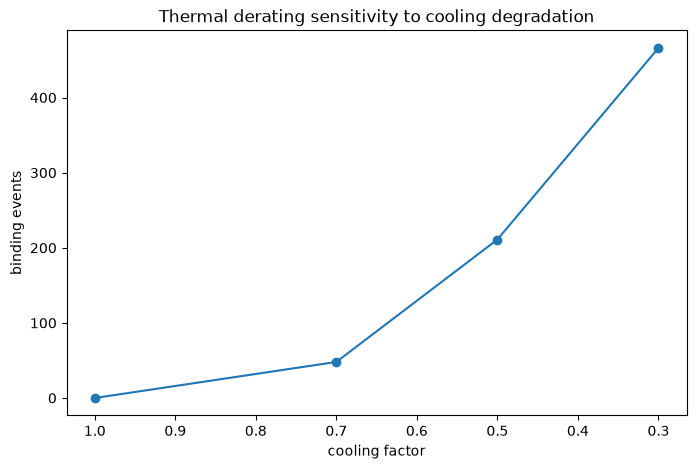

At nominal cooling: 0 binding events
At 30% cooling effectiveness: 466 binding events, mean shortfall 21.0 kW


In [10]:
plt.figure(figsize=(8, 5))
plt.plot(thermal['cfs'], thermal['binding_counts'], 'o-')
plt.xlabel('cooling factor')
plt.ylabel('binding events')
plt.title('Thermal derating sensitivity to cooling degradation')
plt.gca().invert_xaxis()
plt.show()

print(f"At nominal cooling: {thermal['binding_counts'][0]:.0f} binding events")
print(f"At 30% cooling effectiveness: {thermal['binding_counts'][-1]:.0f} binding events, "
      f"mean shortfall {thermal['gap_before_mean']/1e3:.1f} kW")


## 4. Closing the loop: fixed-point self-consistency under degraded cooling

Enforcing a derated bound built from one policy's currents is only self-consistent if the
resulting policy does not draw current differently enough to change the temperature profile
that produced the bound. Under degraded cooling this assumption breaks: a tighter bound
changes the policy, which changes the currents, which changes the temperature. Rather than
promoting temperature to a full third DP state, self-consistency is recovered through
fixed-point iteration between the backward pass and the thermal model, on the same 2D grid.


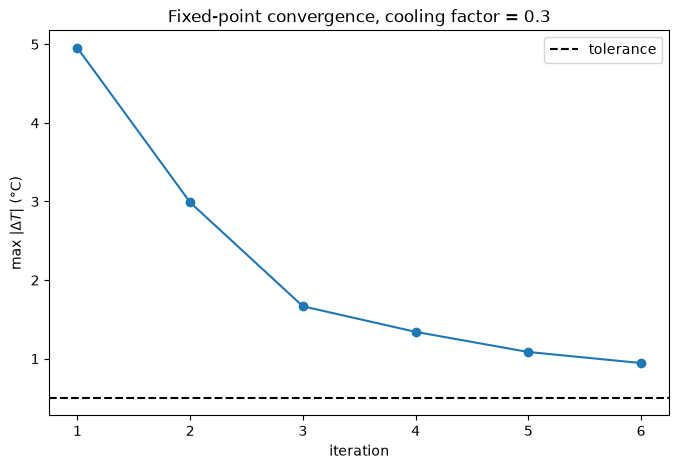

                                Binding events   Mean shortfall (kW)    Fuel (g)
Open-loop (before)                         466                  21.0     2716.80
Fixed-point (after)                        327                   6.2     3495.53


In [11]:
plt.figure(figsize=(8, 5))
deltas = thermal['delta_history']
plt.plot(range(1, len(deltas)+1), deltas, 'o-')
plt.axhline(0.5, color='k', linestyle='--', label='tolerance')
plt.xlabel('iteration')
plt.ylabel(r'max $|\Delta T|$ (°C)')
plt.title('Fixed-point convergence, cooling factor = 0.3')
plt.legend()
plt.show()

print(f"{'':<30}{'Binding events':>16}{'Mean shortfall (kW)':>22}{'Fuel (g)':>12}")
print(f"{'Open-loop (before)':<30}{thermal['binding_before']:>16.0f}{thermal['gap_before_mean']/1e3:>22.1f}{thermal['fuel_nominal']:>12.2f}")
print(f"{'Fixed-point (after)':<30}{thermal['binding_after']:>16.0f}{thermal['gap_after_mean']/1e3:>22.1f}{thermal['fuel_thermal_aware']:>12.2f}")


## Conclusions and future work

- The multi-lap DP baseline is fuel-optimal but not repeatable across laps; an asymmetric
  soft constraint on end-of-lap SoC restores repeatability at a quantified fuel cost, with a
  lap-dependent floor giving the best trade-off between fuel and shortfall reduction.
- Thermal derating is dominated by SoC exhaustion at nominal cooling for this race profile,
  but a parametric stress test shows it becomes binding as cooling effectiveness degrades,
  confirming the framework is thermal-aware even where the nominal result is not
  thermally-limited.
- Fixed-point iteration between the DP policy and the thermal model corrects the open-loop
  assumption at a fraction of the cost of a full 3D state reformulation, a deliberate
  cost/accuracy trade-off made explicit rather than hidden.
- Known simplifications carried through the whole project: `eta_MGU = 1` in the DP/ECMS power
  balance (quantified via the model-plant mismatch between backward and forward pass),
  `R_int` treated as constant, and thermal parameters estimated rather than calibrated against
  a real pack.
- Reinforcement learning (SAC) is deferred as future work, given the September 2026 deadline
  and the priority of finishing this deterministic framework to a high standard first.
